In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import faulthandler, sys
faulthandler.enable(file=sys.stderr)
print("faulthandler enabled", flush=True)

faulthandler enabled


In [3]:
# pip install matplotlib scikit-learn torchdiffeq numpy==2.0.0 jupyterplot siren_pytorch pinnstorch lightning pandas seaborn

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.model_selection import train_test_split
from tqdm.notebook import tqdm
import wandb
import os
from torch import nn
import warnings
warnings.filterwarnings('ignore')
wandb.init(mode="offline")
# os.environ["WANDB_NOTEBOOK_NAME"] = "PINN_GPE.ipynb"
wandb.login(host='http://localhost:8080', 
            key='local-0f9731927571d8659bd45b0d14c25d90e730aa0f')
run = wandb.init(
    project="PINN_0",
    settings=wandb.Settings(
        base_url="http://localhost:8080"
    )
)

# run = wandb.init(mode="offline", project="PINN2")
plt.rcParams.update({"font.size": 16})
sns.set_style("whitegrid")
np.random.seed(0xFA1AFE1)

data = np.load('data_demo/GPE_phase_PHASE_3D_10x10x10_R_7067c_BACKUP_PRESENT_0_intermediate_0.npz')

wandb: Loading settings from /Users/tarkhov/.config/wandb/settings
wandb: ERROR Failed to detect the name of this notebook. You can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.


wandb: WARNING Calling wandb.login() after wandb.init() has no effect.
wandb: [wandb.login()] Loaded credentials for http://localhost:8080 from /Users/tarkhov/.netrc.
wandb: Currently logged in as: tarkhov to http://localhost:8080. Use `wandb login --relogin` to force relogin


wandb: ERROR The nbformat package was not found. It is required to save notebook history.


In [5]:
try:
    if torch.cuda.is_available():
        device = 'cuda:0'
    else:
        device = 'cpu:0'
except:
    device = 'cpu:0'

In [6]:
# device = torch.device("cpu") 

In [7]:
from src.data.dataset import GPEDataset, create_dataloaders
data_ic = GPEDataset('../Thesis/datasets/gpe_simulations/', normalize=False, mode='initial_conditions')
data_traj = GPEDataset('../Thesis/datasets/gpe_simulations/', normalize=False, mode='trajectories')

Found 1000 simulation files
Dataset metadata loaded
Found 1000 simulation files
Dataset metadata loaded


In [8]:
train_loader_ic, val_loader_ic, test_loader_ic = create_dataloaders('../Thesis/datasets/gpe_simulations/', batch_size=2, normalize=False, mode='initial_conditions')
train_loader_traj, val_loader_traj, test_loader_traj = create_dataloaders('../Thesis/datasets/gpe_simulations/', batch_size=2,  normalize=False, mode='trajectories')

Found 1000 simulation files
Dataset metadata loaded
Dataset split: 800 train, 100 val, 100 test
Found 1000 simulation files
Dataset metadata loaded
Dataset split: 800 train, 100 val, 100 test


In [9]:
# beta = 10.
# step = 0.05
beta = 1.
step = 0.001
V = 1000
latent_dim = 128
N_steps = 5000

In [10]:
from src.models.vae import VAE
vae = VAE(2*V, latent_dim=latent_dim)
# vae_chkpt = torch.load('../Thesis/outputs/vae/checkpoints/best_checkpoint.pt')
vae_chkpt = torch.load('outputs/outputs/vae/checkpoints/best_checkpoint.pt')
vae.load_state_dict(vae_chkpt['model_state_dict'], strict=False)

_IncompatibleKeys(missing_keys=['encoder.0.weight', 'encoder.0.bias', 'encoder.2.weight', 'encoder.2.bias', 'fc_mu.weight', 'fc_mu.bias', 'fc_logvar.weight', 'fc_logvar.bias', 'decoder.0.weight', 'decoder.0.bias', 'decoder.2.weight', 'decoder.2.bias', 'decoder.4.weight', 'decoder.4.bias'], unexpected_keys=['encoder.encoder.0.0.weight', 'encoder.encoder.0.0.bias', 'encoder.encoder.0.1.weight', 'encoder.encoder.0.1.bias', 'encoder.encoder.1.0.weight', 'encoder.encoder.1.0.bias', 'encoder.encoder.1.1.weight', 'encoder.encoder.1.1.bias', 'encoder.encoder.2.0.weight', 'encoder.encoder.2.0.bias', 'encoder.encoder.2.1.weight', 'encoder.encoder.2.1.bias', 'encoder.fc_mu.weight', 'encoder.fc_mu.bias', 'encoder.fc_logvar.weight', 'encoder.fc_logvar.bias', 'decoder.decoder_input.weight', 'decoder.decoder_input.bias', 'decoder.decoder.0.0.weight', 'decoder.decoder.0.0.bias', 'decoder.decoder.0.1.weight', 'decoder.decoder.0.1.bias', 'decoder.decoder.1.0.weight', 'decoder.decoder.1.0.bias', 'decoder

In [11]:
# # vae.encode(next(train_loader_ic))
# for item in train_loader_ic:
#     print(item[0].shape, item[1])
#     break
# for item in train_loader_traj:
#     print(item[0].shape, item[1])
#     break

In [12]:
# data_traj[0][0].shape

In [13]:
len(data_traj)#[0]#[0][0]

1000

In [14]:
X, Y = data_traj[0][0][0], data_traj[0][0][1]
print(X.shape, Y.shape)
e = 6
print(data['order_parameters'][0,e,:,:,:,:].real.shape)

torch.Size([10, 10, 10, 5000]) torch.Size([10, 10, 10, 5000])
(10, 10, 10, 1100)


In [15]:
from DGPE.GPElib.lyapunov_generator import LyapunovGenerator
from DGPE.GPElib.dynamics_generator import DynamicsGenerator

dgpe = DynamicsGenerator(N_part_per_well=1.,
                         W=0, disorder_seed=53,
                         N_wells=(10,10,10), dimensionality=3, anisotropy=1.,
                         threshold_XY_to_polar=0.25,
                         J=1, beta=beta,  #beta_disorder_amplitude=2.,
                        integration_method='RK45',
                         rtol=1e-8, atol=1e-8,
                        # smooth_quench=True,
                         smooth_quench_to_room=True,
                         reset_steps_duration=5,
                         calculation_type='lyap_save_all',
                        integrator='scipy',
                        # gpu_integrator='torch',
                        # gpu_id=0,
                         time=51, step=step, t_steps=5000, gamma=1.,
                         quenching_gamma=1.)

e = 6
# dgpe.X, dgpe.Y = data['order_parameters'][0,e,:,:,:,:].real, data['order_parameters'][0,e,:,:,:,:].imag
dgpe.X.shape, dgpe.Y.shape
# dgpe.set_init_XY(data['order_parameters'][0,e,:,:,:,0].real, data['order_parameters'][0,e,:,:,:,0].imag)
dgpe.set_init_XY(X[:,:,:,0], Y[:,:,:,0])
dgpe.step = step
dgpe.n_steps = N_steps
dgpe.icurr = 0
dgpe.inext = 1

dgpe.run_dynamics(no_pert=False)

Geometry:  (10, 10, 10)
Running scipy


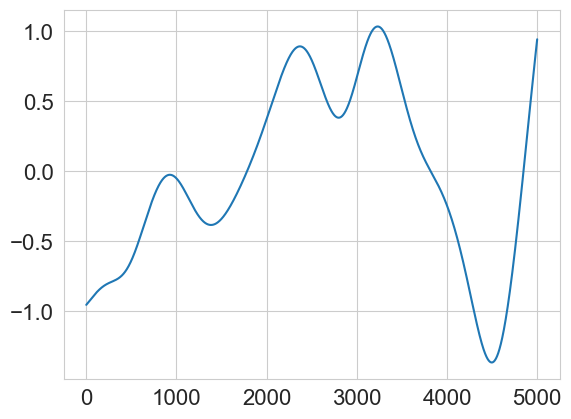

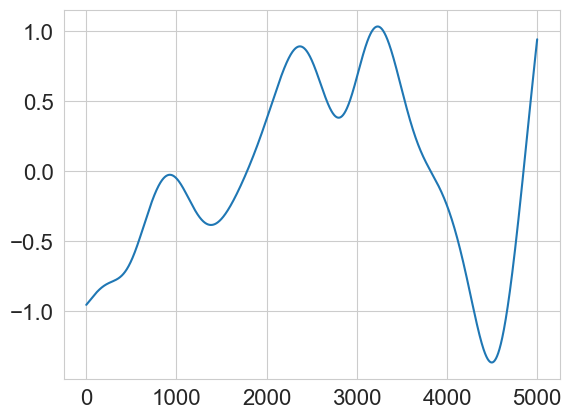

In [16]:
dgpe.X.shape
plt.plot(dgpe.X[0,0,0,:])
plt.show()
plt.plot(X[0,0,0,:].numpy())
plt.show()

In [17]:
j = 0
dgpe.X = data_traj[j][0][0]
dgpe.Y = data_traj[j][0][1]

In [18]:
# wSIM ∝ 1,
# wIBC ∝ exp(− lSIM ,)
# wPDE ∝ exp(− max(lSIM, lIBC),)

In [19]:
j = 0
dgpe.X = data_traj[j][0][0].numpy()
dgpe.Y = data_traj[j][0][1].numpy()

In [20]:
X0, Y0 = data_traj[j][0][0][:,:,:,0], data_traj[j][0][1][:,:,:,0]
print(X0.shape, Y0.shape)
print(torch.stack((X0.flatten(),Y0.flatten())).flatten().shape)
z0 = vae.encode(torch.stack((X0.flatten(),Y0.flatten())).flatten())
z0 = torch.stack(z0).flatten()
print(z0.shape)

torch.Size([10, 10, 10]) torch.Size([10, 10, 10])
torch.Size([2000])
torch.Size([256])


In [21]:
from sklearn.model_selection import train_test_split
import pandas as pd
X = step * np.arange(dgpe.X.shape[-1]).reshape(-1,1)
y = np.hstack((np.moveaxis(dgpe.X, -1, 0).reshape(-1, dgpe.N_wells), np.moveaxis(dgpe.Y, -1, 0).reshape(-1, dgpe.N_wells)))
train_ratio = 0.5
train_size = int(train_ratio * X.shape[0])
X_train_raw = X[:train_size, :]
y_train_raw = y[:train_size]
X_test = X[train_size:, :]
y_test = y[train_size:]
X_train_raw.shape, X_test.shape

X_train, X_val, y_train, y_val = train_test_split(
    X_train_raw, y_train_raw, test_size=1-train_ratio, random_state=0xE2E4
)
X_train.shape, X_val.shape, y_train.shape, y_val.shape

((1250, 1), (1250, 1), (1250, 2000), (1250, 2000))

In [22]:
from src.dgpe_nn import DGPEModule
from src.pinn_lib import train_and_validate, plot_losses
from src.dataloaders import generate_datasets

In [23]:
batch_size = 512
# istride = 500
# istride = 100
istride = 150

train_loader, test_loader, val_loader, init_loader = generate_datasets(X, y, X_train, y_train, X_test, y_test, X_val, y_val, batch_size, istride)

In [24]:
from sklearn.preprocessing import LabelEncoder
n_hidden = 4

n_in, n_out = X.shape[-1] + z0.shape[0], y.shape[-1]
# model = DGPEModule(dgpe, n_in, n_out)

# max_norm = 100.0  # Define a threshold
# torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
# # optimizer = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.95, weight_decay=1e-3)
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3)#, momentum=0.95, weight_decay=1e-3)
# def crit(x,y):
#     print(x.shape, y.shape)
#     return nn.MSELoss()(x,y)
# # criterion = nn.MSELoss()
# criterion = crit
# metric = lambda x,y: nn.MSELoss()(x, y)
# num_epochs = 30

# wandb.watch(model, criterion, log="all", log_freq=10) # Log gradients and parameters

In [25]:
from sklearn.preprocessing import LabelEncoder
n_hidden = 128
# n_hidden = 32
# n_hidden = 8
# n_hidden = 4

# n_in, n_out = X.shape[-1], y.shape[-1]

model = DGPEModule(dgpe, n_in, n_out, n_hidden=n_hidden)
model2 = DGPEModule(dgpe, n_in, n_out, n_hidden=n_hidden)
# max_norm = 100.0  # Define a threshold
# torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3,  weight_decay=1e-3)
#clip gradients
# torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=100.0)

criterion = nn.MSELoss()
metric = lambda x,y: nn.MSELoss()(x, y)
num_epochs = 30
wandb.watch(model, criterion, log="all", log_freq=10) # Log gradients and parameters
wandb.watch(model2, criterion, log="all", log_freq=10) # Log gradients and parameters

In [26]:
total_params = sum(p.numel() for p in model.parameters())
print(total_params)

1072752


In [27]:
# vae.encode(psi)
# vae.encoder.forward(psi)

In [28]:
ne = 10
max_grad = 1e+3
N1, N2, N3 = 3, 30, 300
stages = [
    # (lr, epochs_mult, flags)
    (1e-5, N1, dict(criterion_init_cond=True)),
    (1e-5, N1, dict(criterion_init_cond=True, criterion_ibound=True)),
    (1e-5, N1, dict(criterion_init_cond=True, criterion_ibound=True, criterion_Nconst=True)),
    (1e-5, N1, dict(criterion_init_cond=True, criterion_ibound=True, criterion_Nconst=True, criterion_Econst=True)),
    (1e-5, N1, dict(criterion_init_cond=True, criterion_ibound=True, criterion_Nconst=True, criterion_Econst=True, criterion_pinn=True)),
    
    (1e-3, N2, dict(criterion_init_cond=True)),
    (1e-3, N2, dict(criterion_init_cond=True, criterion_ibound=True)),
    (1e-3, N2, dict(criterion_init_cond=True, criterion_ibound=True, criterion_Nconst=True)),
    (1e-3, N2, dict(criterion_init_cond=True, criterion_ibound=True, criterion_Nconst=True, criterion_Econst=True)),
    (1e-3, N3, dict(criterion_init_cond=True, criterion_ibound=True, criterion_Nconst=True, criterion_Econst=True, criterion_pinn=True)),
]

for lr, emult, flags in stages:
    optimizer = torch.optim.LBFGS(model.parameters(), lr=lr)
    num_epochs = emult * ne
    train_and_validate(
        model, optimizer, criterion, metric,
        train_loader, val_loader, init_loader,
        num_epochs,
        w1=1., w2=1., w3=1., w4=1e-3, w5=1e-6, w6=1., w7=1.,
       run=run, verbose=False,
       patience = 10,
       max_grad_norm=max_grad,
        vae=vae,
        **flags,
    )

In [29]:
ne = 10
max_grad = 1e+3
N1, N2, N3 = 3, 30, 300
stages = [
    # (lr, epochs_mult, flags)
    (1e-5, N1, dict(criterion_init_cond=True)),
    (1e-5, N1, dict(criterion_init_cond=True, criterion_ibound=True)),
    (1e-5, N1, dict(criterion_init_cond=True, criterion_ibound=True, criterion_Nconst=True)),
    (1e-5, N1, dict(criterion_init_cond=True, criterion_ibound=True, criterion_Nconst=True, criterion_Econst=True)),
    (1e-5, N1, dict(criterion_init_cond=True, criterion_ibound=True, criterion_Nconst=True, criterion_Econst=True, criterion_pinn=False)),
    
    (1e-3, N2, dict(criterion_init_cond=True)),
    (1e-3, N2, dict(criterion_init_cond=True, criterion_ibound=True)),
    (1e-3, N2, dict(criterion_init_cond=True, criterion_ibound=True, criterion_Nconst=True)),
    (1e-3, N2, dict(criterion_init_cond=True, criterion_ibound=True, criterion_Nconst=True, criterion_Econst=True)),
    (1e-3, N3, dict(criterion_init_cond=True, criterion_ibound=True, criterion_Nconst=True, criterion_Econst=True, criterion_pinn=False)),
]

for lr, emult, flags in stages:
    optimizer = torch.optim.LBFGS(model2.parameters(), lr=lr)
    num_epochs = emult * ne
    train_and_validate(
        model2, optimizer, criterion, metric,
        train_loader, val_loader, init_loader,
        num_epochs,
        w1=1., w2=1., w3=1., w4=1e-3, w5=1e-6, w6=1., w7=1.,
       run=run, verbose=False,
       patience = 10,
       max_grad_norm=max_grad,
        vae=vae,
        **flags,
    )

In [30]:
# print(z0.shape, t.shape)
# torch.cat((t, z0)).shape

In [31]:
dgpe.X.shape, dgpe.Y.shape

((10, 10, 10, 5000), (10, 10, 10, 5000))

In [32]:
psi_exp = np.hstack((np.moveaxis(dgpe.X, -1,0).reshape(N_steps, -1), 
          np.moveaxis(dgpe.Y, -1,0).reshape(N_steps, -1)))
psi_exp.shape

(5000, 2000)

In [33]:
ts = torch.tensor(step*np.arange(N_steps), dtype=torch.float32, requires_grad=False).reshape(-1,1)
z0s = z0.broadcast_to(N_steps, z0.shape[0])
ts.shape, z0s.shape

(torch.Size([5000, 1]), torch.Size([5000, 256]))

In [34]:
input_params = torch.concat((ts, z0s), 1)
input_params.shape

torch.Size([5000, 257])

In [35]:
# psi = model(torch.cat((t, z0)))
psi = model(input_params)

In [36]:
psi = psi.detach().numpy()
psi.shape

(5000, 2000)

In [37]:
psi2 = model2(input_params)
psi2 = psi2.detach().numpy()


In [38]:
psi_exp.shape

(5000, 2000)

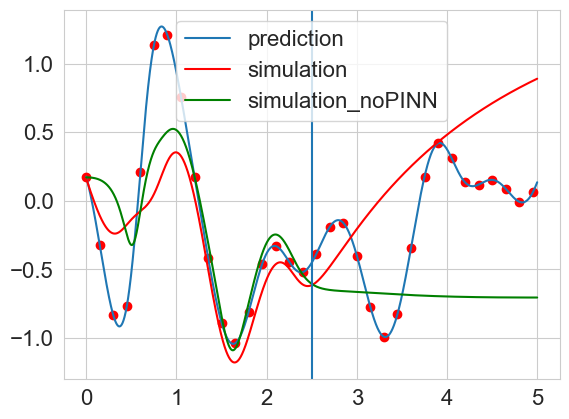

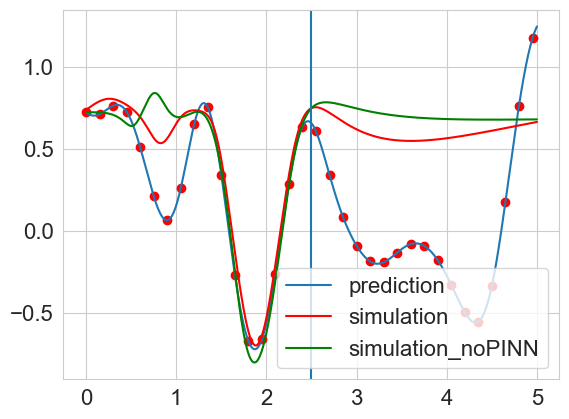

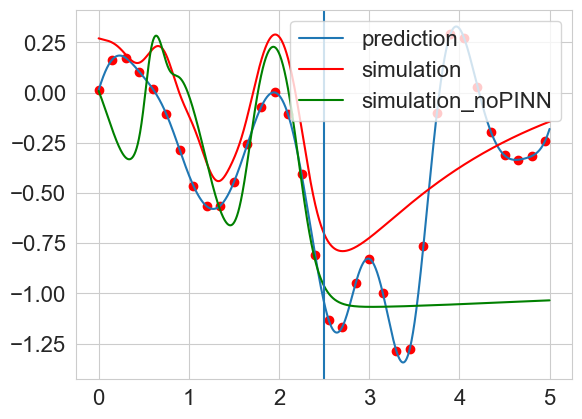

In [39]:
time = np.arange(N_steps) * step
for i_plot in np.random.randint(0, 2000, 3):
    plt.plot(time, psi_exp[:,i_plot], label='prediction')
    plt.plot(time, psi[:,i_plot], color='r', label='simulation')
    plt.plot(time, psi2[:,i_plot], color='g', label='simulation_noPINN')
    plt.scatter(time[::istride], psi_exp[::istride, i_plot], color='r')
    plt.axvline(0.5*time[-1])
    plt.legend()
    plt.show()

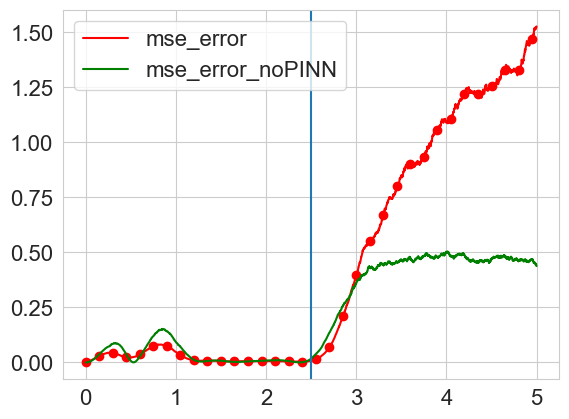

In [40]:
mse_err = np.median((psi - psi_exp) ** 2, axis=1)
mse_err2 = np.median((psi2 - psi_exp) ** 2, axis=1)
time = np.arange(N_steps) * step
plt.plot(time, mse_err, color='r', label='mse_error')
plt.plot(time, mse_err2, color='g', label='mse_error_noPINN')
plt.scatter(time[::istride], mse_err[::istride], color='r')
plt.axvline(0.5*time[-1])
plt.legend()
# plt.yscale('log')
plt.show()

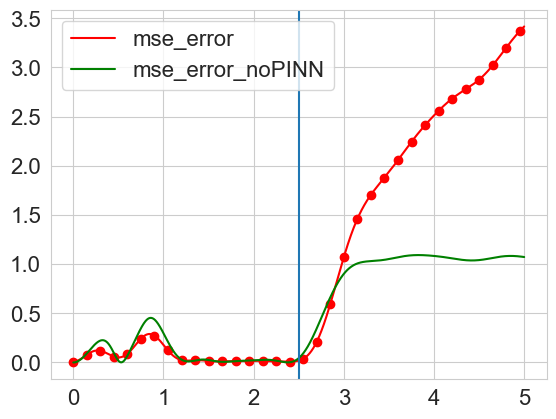

In [41]:
mse_err = np.mean((psi - psi_exp) ** 2, axis=1)
mse_err2 = np.mean((psi2 - psi_exp) ** 2, axis=1)
time = np.arange(N_steps) * step
plt.plot(time, mse_err, color='r', label='mse_error')
plt.plot(time, mse_err2, color='g', label='mse_error_noPINN')
plt.scatter(time[::istride], mse_err[::istride], color='r')
plt.axvline(0.5*time[-1])
plt.legend()
# plt.yscale('log')
plt.show()

In [42]:
# https://en.wikipedia.org/wiki/Kosambi%E2%80%93Karhunen%E2%80%93Lo%C3%A8ve_theorem

In [43]:
# chrome-extension://efaidnbmnnnibpcajpcglclefindmkaj/https://ocw.mit.edu/courses/18-s096-matrix-calculus-for-machine-learning-and-beyond-january-iap-2023/mit18_s096iap23_lec09.pdf

In [44]:
1

1